# Main notebook

### Init

In [82]:
# git add .
# git commit -m "message"
# git push origin main


%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import numpy as np
import torch
import deepchem as dc

from src.data.data import load_data, print_mol_types, featurize
from src.data.preprocess import keep_largest, salt_remover, preprocess, preprocess_conc
from src.utils.plotting import plot_smiles, plot_metals, plot_training


from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from rdkit.Chem.Draw import IPythonConsole

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Init data

In [94]:
path = Path("Data") / "toxicity_fish.csv"
selected_columns = ["SMILES", "conc"]
cut = 10000
# cut = None

df = load_data(path, selected_columns, cut)

print(df.head())
print("")
print_mol_types(df)

       SMILES  conc
0  O=[O+][O-]  0.18
1  O=[O+][O-]  0.18
2  O=[O+][O-]  0.26
3  O=[O+][O-]  0.26
4  O=[O+][O-]  0.17

Total molecules: 10000
Unique molecules: 2738
Salts: 3023, 30.23%
Single atoms: 62, 0.62%
Metals: 3098, 30.98%


### Data analysis

       SMILES  conc
0  O=[O+][O-]  0.18
1  O=[O+][O-]  0.18
2  O=[O+][O-]  0.26
3  O=[O+][O-]  0.26
4  O=[O+][O-]  0.17


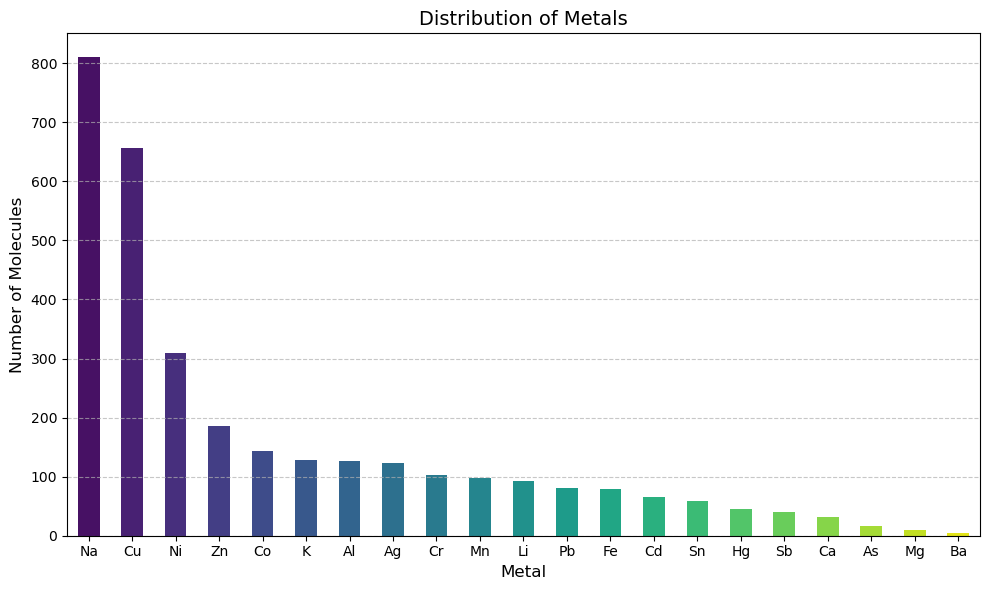

In [95]:
# Mol types and metals

mol_id = 16
print(df.head())

plot_metals(df)

### Data processing

In [96]:
# Preprocess by splitting salts, removing lone atoms and removing metals, also converting concentrations to log scale
# df_pp = preprocess(df, split_salts=True, remove_lone=False, remove_metals=False)

# print(df_pp.head())
# print("")
# print_mol_types(df_pp)

In [97]:
# df["conc"] = df["conc"].apply(lambda x: preprocess_conc(x))
df["log10c"] = df["conc"].apply(lambda x: np.log10(x))
print(df.head())

       SMILES  conc    log10c
0  O=[O+][O-]  0.18 -0.744727
1  O=[O+][O-]  0.18 -0.744727
2  O=[O+][O-]  0.26 -0.585027
3  O=[O+][O-]  0.26 -0.585027
4  O=[O+][O-]  0.17 -0.769551


### PyG

In [98]:
from torch_geometric.utils.smiles import from_smiles

# Featurize the data
df["features"] = df["SMILES"].apply(lambda x: from_smiles(x))

print(df["features"][0])
print("")
print(df.head())
print("")
print(f"Length of dataset: {len(df)}")

Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]')

       SMILES  conc    log10c  \
0  O=[O+][O-]  0.18 -0.744727   
1  O=[O+][O-]  0.18 -0.744727   
2  O=[O+][O-]  0.26 -0.585027   
3  O=[O+][O-]  0.26 -0.585027   
4  O=[O+][O-]  0.17 -0.769551   

                                            features  
0  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
1  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
2  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
3  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
4  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  

Length of dataset: 10000


In [99]:
from torch_geometric.utils.smiles import from_smiles

features = []
for i, smile in enumerate(df["SMILES"]):
    g = from_smiles(smile)
    g.x = g.x.float()
    y = torch.tensor(df["log10c"][i], dtype=torch.float)
    g.y = y
    features.append(g)

print(type(features[0]))
print(features[0])
print(len(features))

<class 'torch_geometric.data.data.Data'>
Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]', y=-0.7447274923324585)
10000


In [100]:
mol_id = 16

print(type(features[mol_id]))

print(features[mol_id])
print("")
# node_features: n_atoms x n_node_features
# - atomic_num, chirality, degree, formal_charge, num_hs, num_radical_r, hybridization, is_aromatic, is_in_ring
print("Node features for one atom example:")
print(features[mol_id].x[0])
# edge_index: 2 x n_edges (source and target) - shows bonds
# edge_features: n_edges x n_edge_features
# -  bond_type, stereo, is_conjugated
print("Edge features for one bond example:")
print(features[mol_id].edge_attr[0])

<class 'torch_geometric.data.data.Data'>
Data(x=[9, 9], edge_index=[2, 18], edge_attr=[18, 3], smiles='Nc1ccc(Cl)c(Cl)c1', y=1.1238516569137573)

Node features for one atom example:
tensor([7., 0., 3., 5., 2., 0., 3., 0., 0.])
Edge features for one bond example:
tensor([1, 0, 1])


In [101]:
from torch.utils.data import random_split
# Create a dataset
train_ratio = 0.8
train_size = int(train_ratio * len(features))
test_size = len(features) - train_size

train_dataset, test_dataset = random_split(features, [train_size, test_size]) # look at better splitter?

print(type(train_dataset))
print(f"Train set size: {len(train_dataset)} - {len(train_dataset) / len(features) * 100:.2f}%")
print(f"Test set size: {len(test_dataset)} - {len(test_dataset) / len(features) * 100:.2f}%")

<class 'torch.utils.data.dataset.Subset'>
Train set size: 8000 - 80.00%
Test set size: 2000 - 20.00%


In [102]:
from torch_geometric.loader import DataLoader
# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(type(train_loader))

<class 'torch_geometric.loader.dataloader.DataLoader'>


# GNN

In [103]:
import torch
from src.model.model import ToxGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = ToxGNN(
    mol_dim=9,
    hidden_dim=64
).to(device)



Device: cpu


### Training

Epoch 0: Train Loss = 1.8292, Val Loss = 1.7032
Epoch 10: Train Loss = 1.3168, Val Loss = 1.2771
Epoch 20: Train Loss = 1.1114, Val Loss = 1.1461
Epoch 30: Train Loss = 0.9921, Val Loss = 0.9849
Epoch 40: Train Loss = 0.9430, Val Loss = 1.0078
Epoch 50: Train Loss = 0.8745, Val Loss = 0.8923
Epoch 60: Train Loss = 0.8258, Val Loss = 0.8347
Epoch 70: Train Loss = 0.7818, Val Loss = 0.8233
Epoch 80: Train Loss = 0.7768, Val Loss = 0.7879
Epoch 90: Train Loss = 0.7244, Val Loss = 0.7561


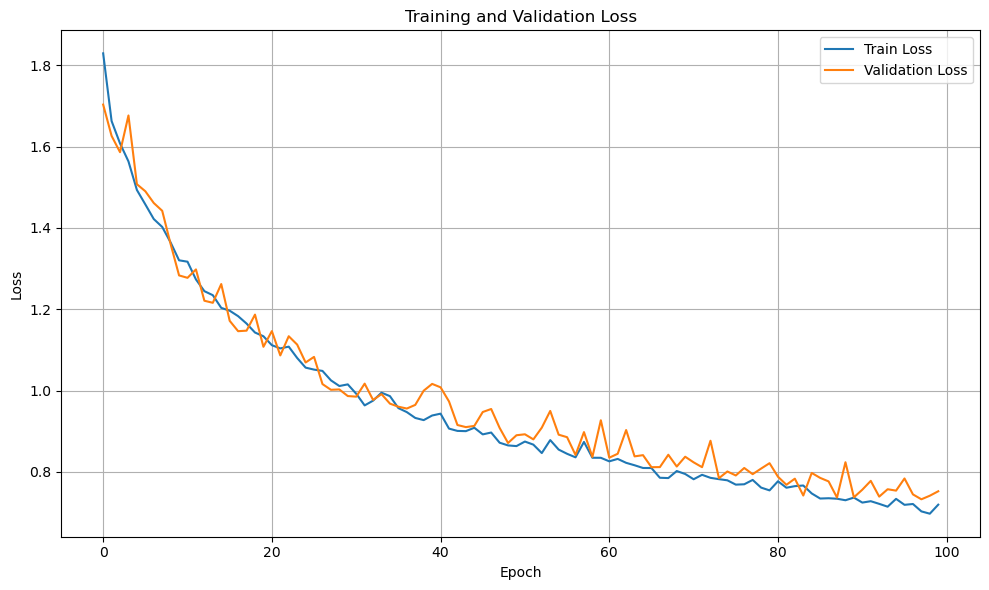

In [104]:
from src.model.eval import train
from src.utils.plotting import plot_training

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model, history = train(model, train_loader, test_loader, loss_fn=loss_fn, optimizer=optimizer, epochs=100, device=device)

plot_training(history)
